In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import ast


In [17]:
df = pd.read_csv("../data/processed_sold_dataset_v6_update_gpt.csv")

df.head()


,post_id,text,tokens,label,stereotype,category,text_length,off_word_count,rationales,offensive_words,...,C19,C20,C21,C22,C23,C24,C25,C26,C27,C28
0,995411387894542336,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,"['තේ', 'නෙවෙයි', 'තෝ', 'බීලා', 'ඉන්නෙ', 'ගිනි'...",OFF,0,['Gender'],33,1,"['0', '0', '1', '0', '0', '0', '0']",['තෝ'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1128238706303864832,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,"['@USER', 'තුනක්', 'ඕනේ', 'නෑ', 'එකක්', 'ගැහුව...",OFF,0,['Gender'],74,1,"['0', '0', '1', '0', '0', '0', '0', '0', '0', ...",['ඕනේ'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1290554471714496514,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...","['@USER', ',', '@USER', '@USER', 'ටහුඩු', 'ඒකි...",OFF,0,['Gender'],76,4,"['0', '0', '0', '0', '1', '1', '0', '0', '1', ...","['ටහුඩු', 'ඒකි', 'වෙන්න', 'වෙන්න']",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,909459929446182913,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,"['@USER', 'මර්විනුත්', 'මුද්දරයක්', 'වෙයිද', '...",NOT,0,[],40,0,"['0', '0', '0', '0', '0', '0']",[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1305480579375198208,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"['@USER', 'ගොසිප්', 'පීපල්', 'නෙමේ', 'හුත්තො',...",OFF,0,['Gender'],83,3,"['0', '0', '0', '0', '1', '0', '1', '0', '1', ...","['හුත්තො', 'තෝ', 'හොරෙක්ට']",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.shape


(10000, 27)

In [19]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          10000 non-null  int64  
 1   text             10000 non-null  str    
 2   tokens           10000 non-null  str    
 3   label            10000 non-null  str    
 4   stereotype       10000 non-null  int64  
 5   category         10000 non-null  str    
 6   text_length      10000 non-null  int64  
 7   off_word_count   10000 non-null  int64  
 8   rationales       10000 non-null  str    
 9   offensive_words  10000 non-null  str    
 10  target_type      10000 non-null  str    
 11  target_group     0 non-null      float64
 12  C14              0 non-null      float64
 13  C15              0 non-null      float64
 14  C16              0 non-null      float64
 15  C17              0 non-null      float64
 16  C18              0 non-null      float64
 17  C19              0 non-n

In [20]:
df.isnull().sum()


post_id                0
text                   0
tokens                 0
label                  0
stereotype             0
category               0
text_length            0
off_word_count         0
rationales             0
offensive_words        0
target_type            0
target_group       10000
C14                10000
C15                10000
C16                10000
C17                10000
C18                10000
C19                10000
C20                10000
C21                10000
C22                 9999
C23                 9999
C24                10000
C25                10000
C26                10000
C27                 9999
C28                10000
dtype: int64

In [21]:
# 6. Label Distribution
df['label'].value_counts()


label
OFF    8618
NOT    1382
Name: count, dtype: int64

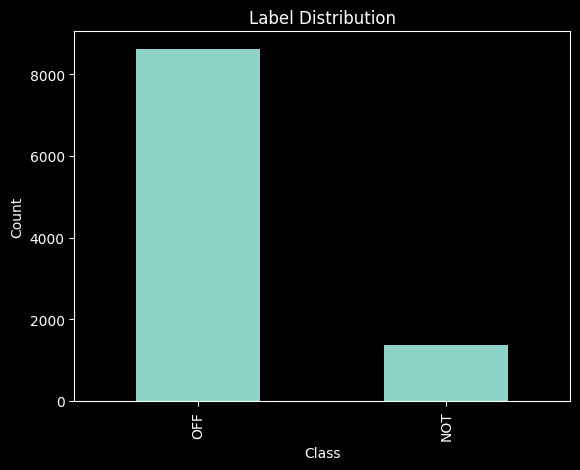

In [22]:
df['label'].value_counts().plot(kind='bar')

plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [23]:
# 7. Convert Token Columns
df['tokens'] = df['tokens'].apply(lambda x: str(x).split())

df['rationales'] = df['rationales'].apply(ast.literal_eval)


In [24]:
# # 8. Extract Offensive Words
# def extract_offensive_words(row):
#
#     tokens = row['tokens']
#     rationales = row['rationales']
#
#     offensive_words = []
#
#     for t,r in zip(tokens,rationales):
#         if r == 1:
#             offensive_words.append(t)
#
#     return offensive_words


In [25]:
# df['offensive_words'] = df.apply(extract_offensive_words, axis=1)

df[['text','offensive_words']].head()


,text,offensive_words
0,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,['තෝ']
1,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,['ඕනේ']
2,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...","['ටහුඩු', 'ඒකි', 'වෙන්න', 'වෙන්න']"
3,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,[]
4,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"['හුත්තො', 'තෝ', 'හොරෙක්ට']"


In [26]:
# 9. Offensive Word Frequency
off_words = df['offensive_words'].explode()

off_words.value_counts().head(20)


offensive_words
[]            1382
['පට්ට']       125
['යකෝ']        124
['තෝ']         119
['එක']          98
['පිස්සු']      92
['රෙද්ද']       83
['පලයන්']       74
['ටහුඩු']       71
['අයිසෙ']       68
['ඒකි']         66
['අඩො']         63
['කෑල්ල']       63
['කටට']         62
['හෙන']         61
['ගොනා']        58
['උඹ']          58
['මෝඩ']         58
['කැත']         57
['පිස්සා']      55
Name: count, dtype: int64

In [27]:
# 10. Word Frequency in Dataset
all_words = " ".join(df['text']).lower().split()

word_freq = Counter(all_words)

word_freq.most_common(20)


[('@user', 8594),
 ('මේ', 1549),
 ('එක', 1367),
 ('url', 1004),
 ('.', 981),
 ('වගේ', 977),
 ('නෑ', 920),
 ('ඒ', 916),
 ('කියලා', 881),
 ('නම්', 709),
 ('·', 664),
 ('එකක්', 653),
 ('කරන්න', 653),
 ('දැන්', 599),
 ('ඉන්න', 589),
 ('යකෝ', 562),
 ('තෝ', 548),
 ('මට', 527),
 ('මම', 527),
 ('අපි', 527)]

In [28]:
# 11. Text Length Analysis

df['text_length'] = df['text'].apply(len)

df['text_length'].describe()


count    10000.000000
mean       118.464000
std         85.871329
min         18.000000
25%         54.000000
50%         95.000000
75%        152.000000
max        634.000000
Name: text_length, dtype: float64

In [29]:
# 12. Compare Offensive vs Non-Offensive Length
df.groupby('label')['text_length'].mean()


label
NOT     77.952243
OFF    124.960548
Name: text_length, dtype: float64

In [40]:
# 13. Offensive Word Count Per Post
df['off_word_count'] = df['offensive_words'].apply(len)

df[['text','off_word_count']]


,text,off_word_count
0,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,6
1,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,7
2,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...",34
3,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,2
4,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,27
...,...,...
9995,අද උදේ දැක්කා පට්ට ලස්සන හීනයක්,8
9996,@USER කසල වෙන් කරලා දෙන්න පුරුදු වුනොත් වැඩේ ...,9
9997,ඒත් පබාගේ පස්ස නම්... ඉස්සෝ කොටුවක් උනත් දාන්න...,17
9998,සුදුවෑන්වලට මාරම මාර බයක් තියෙන ඈයෝ අන්තවාදයට...,27


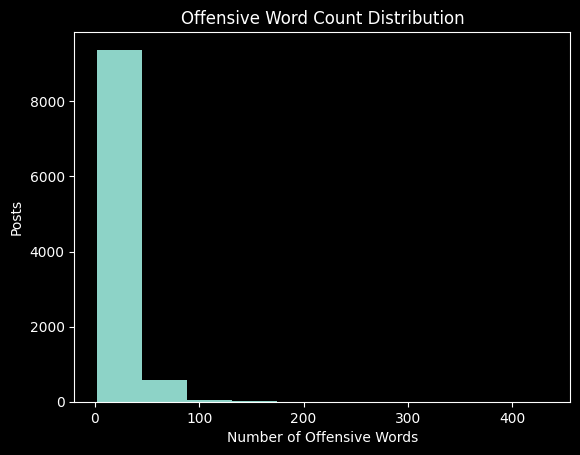

In [41]:
# 14. Distribution of Offensive Words
df['off_word_count'].plot(kind='hist',)

plt.title("Offensive Word Count Distribution")
plt.xlabel("Number of Offensive Words")
plt.ylabel("Posts")
plt.show()


In [32]:
# 15. Separate Offensive Posts
offensive_df = df[df['label']=="OFF"]

offensive_df.head()


,post_id,text,tokens,label,stereotype,category,text_length,off_word_count,rationales,offensive_words,...,C19,C20,C21,C22,C23,C24,C25,C26,C27,C28
0,995411387894542336,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,"[['තේ',, 'නෙවෙයි',, 'තෝ',, 'බීලා',, 'ඉන්නෙ',, ...",OFF,0,['Gender'],33,6,"[0, 0, 1, 0, 0, 0, 0]",['තෝ'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1128238706303864832,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,"[['@USER',, 'තුනක්',, 'ඕනේ',, 'නෑ',, 'එකක්',, ...",OFF,0,['Gender'],74,7,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",['ඕනේ'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1290554471714496514,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...","[['@USER',, ',',, '@USER',, '@USER',, 'ටහුඩු',...",OFF,0,['Gender'],76,34,"[0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0]","['ටහුඩු', 'ඒකි', 'වෙන්න', 'වෙන්න']",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1305480579375198208,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"[['@USER',, 'ගොසිප්',, 'පීපල්',, 'නෙමේ',, 'හුත...",OFF,0,['Gender'],83,27,"[0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]","['හුත්තො', 'තෝ', 'හොරෙක්ට']",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1223789724063522816,අපිට නම් පෙන්නන්න තියෙන්නේ මේ ගල තමා! සුදු නෑ ...,"[['අපිට',, 'නම්',, 'පෙන්නන්න',, 'තියෙන්නේ',, '...",OFF,0,['Gender'],77,12,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",['පෙන්නන්න'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# 16. Create Offensive Word Dataset
offensive_dataset = offensive_df[['text','offensive_words']]

offensive_dataset.head()


,text,offensive_words
0,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,['තෝ']
1,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,['ඕනේ']
2,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...","['ටහුඩු', 'ඒකි', 'වෙන්න', 'වෙන්න']"
4,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"['හුත්තො', 'තෝ', 'හොරෙක්ට']"
5,අපිට නම් පෙන්නන්න තියෙන්නේ මේ ගල තමා! සුදු නෑ ...,['පෙන්නන්න']


In [34]:
# 17. Add Stereotype Annotation Column
# df['stereotype'] =


In [35]:
# 18. Save Processed Dataset
# df.to_csv("/processed_sold_dataset.csv", index=False)


In [36]:
# 19. Save Offensive Word List
# off_words.value_counts().to_csv("/offensive_word_frequency.csv")


# **Analysis** 

In [43]:
# !wget https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [45]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "../data/font/NotoSansSinhala-Regular.ttf"   # correct path

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()


In [49]:
from matplotlib import font_manager

# Register your downloaded font
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

# Set the global font family to something that handles English,
# then add Sinhala as a specific override for those characters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Noto Sans Sinhala']

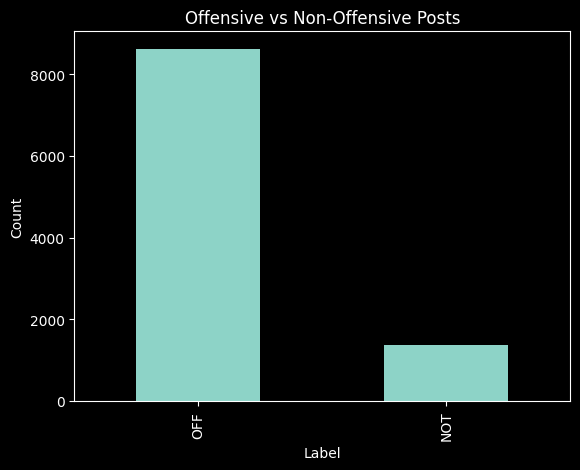

In [50]:
# 1. Label Distribution (Bar Chart)

# Shows how many OFF vs NOT posts exist.
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Offensive vs Non-Offensive Posts")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


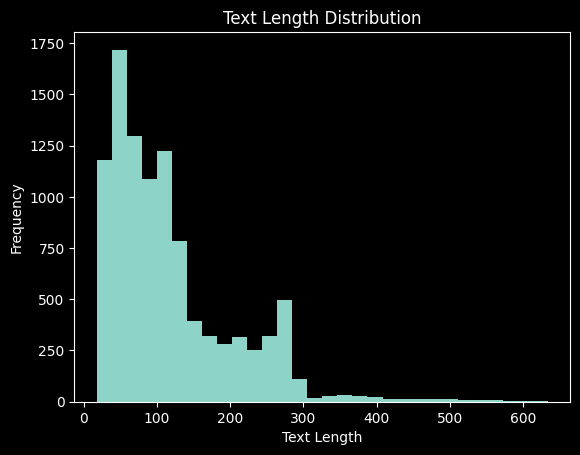

In [51]:
# 2. Text Length Distribution (Histogram)
df['text_length'] = df['text'].apply(len)

plt.hist(df['text_length'], bins=30)

plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


C:\Users\Shashikala\AppData\Local\Temp\ipykernel_8776\3290334393.py:20: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout()
C:\Users\Shashikala\AppData\Local\Temp\ipykernel_8776\3290334393.py:20: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout()
C:\Users\Shashikala\AppData\Local\Temp\ipykernel_8776\3290334393.py:20: UserWarning: Glyph 79 (O) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout()
C:\Users\Shashikala\AppData\Local\Temp\ipykernel_8776\3290334393.py:20: UserWarning: Glyph 102 (f) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout()
C:\Users\Shashikala\AppData\Local\Temp\ipykernel_8776\3290334393.py:20: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout()
C:\Users\Shashikala\AppData\Local\Temp\ipykernel_8776\3290334393.py:20: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans Sinhala.
  plt.tight_layout()
C:\Users\Shashikala\AppData\Local\Temp\ip

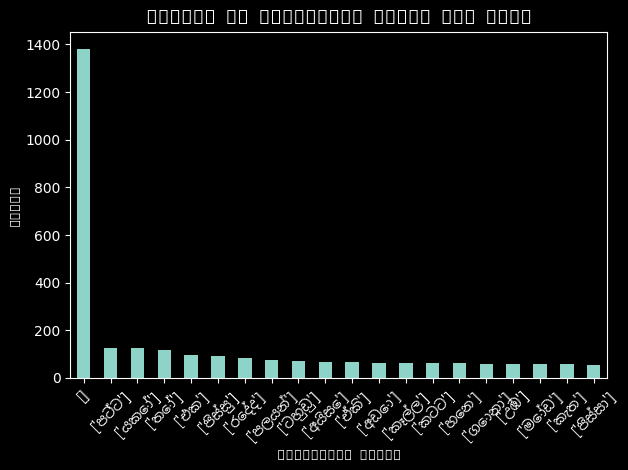

In [60]:
# 2. Prepare the data
off_words = df['offensive_words'].explode()
off_words = off_words[off_words != ""]
top_words = off_words.value_counts().head(20)

# 3. Create the plot
ax = top_words.plot(kind='bar')

# 4. APPLY THE FONT TO THE X-AXIS (This is the magic part)
# This loops through each word on the bottom and sets the Sinhala font
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)

# 5. Set titles (also using the Sinhala font if needed)
plt.title("Number of Offensive Words per Post", fontproperties=prop, fontsize=14)
plt.xlabel("Offensive Words", fontproperties=prop)
plt.ylabel("Posts", fontproperties=prop)

plt.xticks(rotation=45) # Rotates words so they don't overlap
plt.tight_layout()
plt.show()


C:\Users\Shashikala\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Shashikala\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Shashikala\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 70 (F) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Shashikala\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Shashikala\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Sinhala.
  f

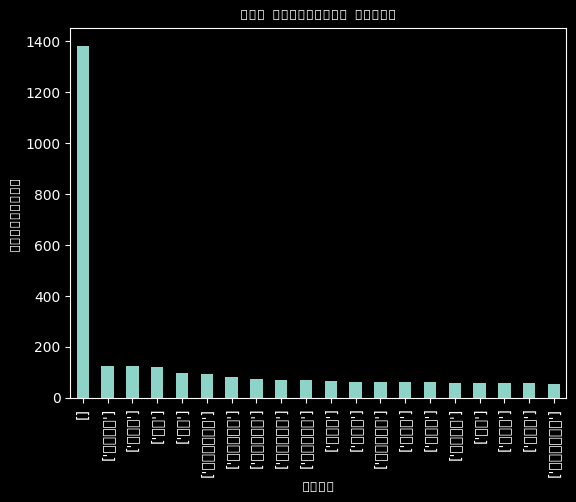

In [62]:
# 4. Top Offensive Words (Bar Chart)
from collections import Counter

off_words = df['offensive_words'].explode()

top_words = off_words.value_counts().head(20)
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)
top_words.plot(kind='bar')

plt.title("Top Offensive Words", fontproperties=prop, )
plt.xlabel("Word",fontproperties=prop,)
plt.ylabel("Frequency",fontproperties=prop,)

plt.show()


In [63]:
# 5. Word Cloud Visualization
!pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


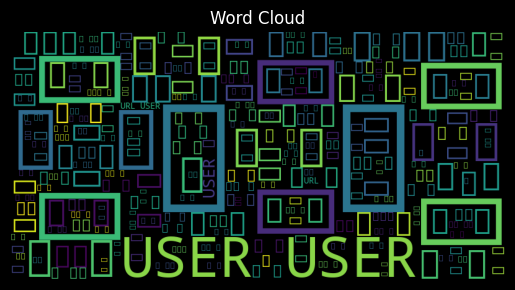

In [64]:
from wordcloud import WordCloud

text = " ".join(df['text'])

wordcloud = WordCloud(width=800,height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()


In [ ]:
# 6. Offensive vs Non-Offensive Text Length
df.groupby('label')['text_length'].mean().plot(kind='bar')

plt.title("Average Text Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Length")
plt.show()


In [ ]:
# 7. Offensive Word Frequency Pie Chart
top_words.head(10).plot(kind='pie', autopct='%1.1f%%')

plt.title("Top Offensive Word Share")
plt.ylabel("")
plt.show()
